# nb04 — (b) портфель на $1000: деньги, просадка, лимиты по инструменту

Шаг (a) показал, что при формации **в один месяц** среднее за сделку ≈ 0 до хвоста
и отрицательно с ним. Важная поправка к границам этого вывода: проверено **одно**
окно формации и одно z-окно, поэтому корректная формулировка — «при таком замере
сигнала не видно», а не «сигнала нет». Свип длины формации — следующий шаг.

Здесь строим то, без чего дальше нельзя: **портфельный движок**.

Что меряем:
1. **Деньги и просадку** на $1000 — не «среднее за сделку», а кривую капитала
   с mark-to-market просадкой.
2. **Два режима лимита по инструменту** (запрос пользователя):
   - **MULTI** — символ может участвовать в нескольких позициях одновременно
     (если сигнал пришёл по многим парам с этой ногой);
   - **SINGLE** — по каждому символу максимум одна открытая позиция.
   Это прямая проверка того, насколько результат зависит от скрытого
   концентрационного риска: 29 одновременных хвостовых позиций из nb03 как раз
   и означают, что одна нога сидела во многих парах.
3. **Рыночную экспозицию портфеля** во времени и связь PnL с трендовостью рынка —
   проверка опыта пользователя: «парная стратегия умирала, когда весь рынок
   становился трендовым».

Правила портфеля (зафиксированы до прогонов):
- капитал **$1000**, gross notional одной позиции = **2% от текущего капитала**
  (две ноги вместе), то есть 50 позиций = 100% gross, без плеча;
- общий gross ограничен **100% капитала**; сигналы сверх лимита пропускаются;
- приоритет при конкуренции за лимит — по **|z| на входе**, больше значит раньше;
- косты 21 bps от gross позиции за round-trip (10.5 bps на сторону);
- PnL позиции = `side · Δ(лог-спред) / (1+|β|)` от её gross (подразумевает
  ребалансировку долей — см. nb02 §1.5).

In [1]:
import sys; sys.path.insert(0, ".")
from _lab import *
from statsmodels.tsa.stattools import coint
from itertools import combinations
import time

MIN_DVOL_M = 5.0
STABLES = ["USDCUSDT", "USDEUSDT", "DAIUSDT", "TUSDUSDT", "FDUSDUSDT"]
px = load_panel("close", "1h")
dv = load_panel("dollarvol", "1h")
daily_m = dv.median() * 24 / 1e6
liq = sorted([s for s in px.columns if daily_m[s] >= MIN_DVOL_M and s not in STABLES])
lp = np.log(px[liq])
MONTHS = [str(p) for p in pd.period_range("2024-01", "2025-06", freq="M")]
COST_SIDE = SIDE_BPS / 100          # % от gross за одно пересечение
MKT = np.log(px[liq]).diff().mean(axis=1)      # равновзвешенный рыночный фактор


def month_slice(df, ym):
    p = pd.Period(ym, freq="M")
    return df.loc[pd.Timestamp(p.start_time, tz="UTC"):pd.Timestamp(p.end_time, tz="UTC")]


print(f"символов {len(liq)}, пар {len(liq)*(len(liq)-1)//2}, месяцев {len(MONTHS)}")

символов 43, пар 903, месяцев 18


## 1. Генерация сигналов

Тот же месячный протокол, что в nb02/nb03. Берём два набора правил:

- **RAW** — как в nb02: вход `|z|>2`, выход `|z|<0.5` или конец месяца, без защиты;
- **PROT** — лучший защищённый вариант из nb03 §2 («всё вместе»): фильтр
  β-стабильности, z-стоп 4, лимит удержания 7 дней, без перезахода после стопа.

Для каждой сделки-кандидата сразу сохраняем **почасовую траекторию PnL** (в % от
её собственного gross) — она нужна движку для mark-to-market.

In [2]:
def gen_candidates(zin=2.0, zout=0.5, zstop=None, max_hold=None,
                   reenter=True, beta_stab=None):
    """Кандидаты в сделки по месячному протоколу + почасовая траектория PnL каждой."""
    out = []
    for m_f, m_t in zip(MONTHS[:-1], MONTHS[1:]):
        f, t = month_slice(lp, m_f), month_slice(lp, m_t)
        for a, b in combinations(liq, 2):
            y, x = (a, b) if daily_m[a] <= daily_m[b] else (b, a)
            yv, xv = f[y].values, f[x].values
            p = coint(yv, xv, trend="c", maxlag=1, autolag=None)[1]
            if p >= 0.05:
                continue
            b_lvl = float(np.polyfit(xv, yv, 1)[0])
            if beta_stab is not None:
                b_ret = float(np.polyfit(np.diff(xv), np.diff(yv), 1)[0])
                if b_lvl <= 0 or b_ret <= 0:
                    continue
                if not (beta_stab[0] <= b_lvl / b_ret <= beta_stab[1]):
                    continue
            s_f = yv - b_lvl * xv
            mu, sd = s_f.mean(), s_f.std()
            g = 1 + abs(b_lvl)
            s = (t[y] - b_lvl * t[x])
            sv, idx = s.values, s.index
            zv = (sv - mu) / sd
            n = len(sv)
            zmax = zstop if zstop is not None else np.inf
            i = 0
            while i < n:
                if not (zin < abs(zv[i]) <= zmax):
                    i += 1
                    continue
                side = -1 if zv[i] > 0 else 1
                j, reason = i + 1, "forced"
                while j < n:
                    if abs(zv[j]) < zout:
                        reason = "target"
                        break
                    if zstop is not None and abs(zv[j]) > zstop:
                        reason = "zstop"
                        break
                    if max_hold is not None and (j - i) >= max_hold:
                        reason = "time"
                        break
                    j += 1
                k = min(j, n - 1)
                path = side * (sv[i:k+1] - sv[i]) / g * 100      # % от gross, почасово
                out.append({"y": y, "x": x, "m_t": m_t, "beta": b_lvl, "g": g,
                            "t_in": idx[i], "t_out": idx[k], "side": side,
                            "z_in": zv[i], "reason": reason, "path": path,
                            # net-экспозиция позиции на $1 gross: (side*1 + side*(-beta))/g
                            "net_w": side * (1 - b_lvl) / g})
                if not reenter and reason in ("zstop",):
                    break
                i = k + 1
    return pd.DataFrame(out)


t0 = time.time()
CAND = {"RAW": gen_candidates(),
        "PROT": gen_candidates(zstop=4.0, max_hold=24*7, reenter=False,
                               beta_stab=(0.5, 2.0))}
for k, v in CAND.items():
    print(f"{k}: {len(v)} кандидатов, "
          f"средний PnL сделки {(v.path.apply(lambda p: p[-1]).mean() - 2*COST_SIDE):+.3f}% от gross")
print(f"сгенерировано за {time.time()-t0:.0f}s")

RAW: 4068 кандидатов, средний PnL сделки -0.600% от gross
PROT: 2790 кандидатов, средний PnL сделки -0.044% от gross
сгенерировано за 13s


## 2. Портфельный движок

Событийная симуляция по часовой сетке. На каждом часе: закрываем позиции, у
которых наступил выход, затем открываем новые из кандидатов этого часа, если
проходят лимиты. Считаем mark-to-market капитал (незакрытые позиции переоценены).

Лимиты: общий gross ≤ 100% капитала; в режиме **SINGLE** символ не может входить
в две открытые позиции сразу.

In [3]:
def simulate(cand: pd.DataFrame, one_per_symbol=False, f_pos=0.02,
             start=1000.0, cap_gross=1.0, max_pos=None):
    """Портфель на часовой сетке. Возвращает (equity_mtm, log, stats)."""
    cand = cand.sort_values(["t_in", "z_in"], key=lambda s: s.abs() if s.name == "z_in" else s,
                            ascending=[True, False]).reset_index(drop=True)
    by_hour = {t: g for t, g in cand.groupby("t_in")}
    lo, hi = cand.t_in.min(), cand.t_out.max()
    timeline = px.index[(px.index >= lo) & (px.index <= hi)]

    cash = start                # реализованный капитал
    open_pos = []               # список открытых позиций
    used_syms = set()
    eq_mtm, n_open, gross_ser, net_ser = [], [], [], []
    skipped = {"gross": 0, "symbol": 0, "maxpos": 0}
    done = []

    for h in timeline:
        # 1) закрытие
        still = []
        for p in open_pos:
            if h >= p["t_out"]:
                pnl = p["notional"] * p["path"][-1] / 100 - p["notional"] * 2 * COST_SIDE / 100
                cash += pnl
                done.append({**{k: p[k] for k in ("y", "x", "t_in", "t_out", "side",
                                                  "z_in", "reason", "notional")},
                             "pnl_usd": pnl, "pnl_pct_gross": p["path"][-1] - 2*COST_SIDE})
                if one_per_symbol:
                    used_syms.discard(p["y"]); used_syms.discard(p["x"])
            else:
                still.append(p)
        open_pos = still

        # 2) текущая MTM-оценка (до открытия новых)
        cur_gross = sum(p["notional"] for p in open_pos)
        unreal = 0.0
        for p in open_pos:
            k = min(p["k"], len(p["path"]) - 1)
            unreal += p["notional"] * p["path"][k] / 100
        equity = cash + unreal

        # 3) открытие новых
        if h in by_hour:
            for _, c in by_hour[h].iterrows():
                if max_pos is not None and len(open_pos) >= max_pos:
                    skipped["maxpos"] += 1
                    continue
                if one_per_symbol and (c.y in used_syms or c.x in used_syms):
                    skipped["symbol"] += 1
                    continue
                notional = f_pos * equity
                if cur_gross + notional > cap_gross * equity:
                    skipped["gross"] += 1
                    continue
                open_pos.append({"y": c.y, "x": c.x, "t_in": c.t_in, "t_out": c.t_out,
                                 "side": c.side, "z_in": c.z_in, "reason": c.reason,
                                 "path": c.path, "net_w": c.net_w,
                                 "notional": notional, "k": 0})
                cur_gross += notional
                if one_per_symbol:
                    used_syms.add(c.y); used_syms.add(c.x)

        # 4) шаг переоценки
        for p in open_pos:
            p["k"] += 1
        eq_mtm.append(equity)
        n_open.append(len(open_pos))
        gross_ser.append(cur_gross / equity if equity > 0 else 0)
        net_ser.append(sum(p["notional"] * p["net_w"] for p in open_pos) / equity
                       if equity > 0 else 0)

    eq = pd.Series(eq_mtm, index=timeline)
    log = pd.DataFrame(done)
    dd = eq / eq.cummax() - 1
    daily = eq.resample("1D").last().dropna()
    dr = daily.pct_change().dropna()
    stats = {"итог $": round(eq.iloc[-1], 1),
             "доход %": round((eq.iloc[-1]/start - 1)*100, 1),
             "MTM maxDD %": round(dd.min()*100, 1),
             "Sharpe (дн., год.)": round(dr.mean()/dr.std()*np.sqrt(365), 2) if dr.std() > 0 else np.nan,
             "сделок": len(log),
             "медиана одновр. позиций": int(np.median(n_open)),
             "макс одновр.": int(np.max(n_open)),
             "средний gross %": round(float(np.mean(gross_ser))*100, 1),
             "пропущено (символ)": skipped["symbol"],
             "пропущено (gross)": skipped["gross"]}
    diag = pd.DataFrame({"equity": eq, "n_open": n_open,
                         "gross": gross_ser, "net_exp": net_ser}, index=timeline)
    return eq, log, stats, diag

In [4]:
RUNS = {}
rows = []
for rule in ["RAW", "PROT"]:
    for mode, ops in [("MULTI", False), ("SINGLE", True)]:
        tag = f"{rule}/{mode}"
        eq, log, st, diag = simulate(CAND[rule], one_per_symbol=ops)
        RUNS[tag] = (eq, log, st, diag)
        rows.append({"конфиг": tag, **st})
P = pd.DataFrame(rows)
print("ПОРТФЕЛЬ $1000, TRAIN 2024-02 .. 2025-07 (косты учтены, без плеча)")
print(P.to_string(index=False))

ПОРТФЕЛЬ $1000, TRAIN 2024-02 .. 2025-07 (косты учтены, без плеча)
     конфиг  итог $  доход %  MTM maxDD %  Sharpe (дн., год.)  сделок  медиана одновр. позиций  макс одновр.  средний gross %  пропущено (символ)  пропущено (gross)
  RAW/MULTI   731.5    -26.9        -35.8               -0.66    2443                       47            52             88.1                   0               1625
 RAW/SINGLE   906.3     -9.4        -12.7               -1.30     598                       11            16             21.3                3470                  0
 PROT/MULTI   962.4     -3.8        -13.9               -0.38    2725                       13            50             31.3                   0                 65
PROT/SINGLE   958.0     -4.2         -5.8               -1.71     826                        4            12              8.9                1964                  0


## 3. MULTI против SINGLE: что даёт лимит «одна позиция на символ»

Ключевой вопрос пользователя. Смотрим не только на итог, но и на то, **сколько
сигналов режется** и как меняется концентрация.

In [5]:
for rule in ["RAW", "PROT"]:
    a = RUNS[f"{rule}/MULTI"]
    b = RUNS[f"{rule}/SINGLE"]
    print(f"\n=== {rule} ===")
    print(f"  MULTI : сделок {a[2]['сделок']:>4}, итог {a[2]['доход %']:+7.1f}%, "
          f"maxDD {a[2]['MTM maxDD %']:+6.1f}%, медиана позиций {a[2]['медиана одновр. позиций']:>2}, "
          f"макс {a[2]['макс одновр.']:>3}")
    print(f"  SINGLE: сделок {b[2]['сделок']:>4}, итог {b[2]['доход %']:+7.1f}%, "
          f"maxDD {b[2]['MTM maxDD %']:+6.1f}%, медиана позиций {b[2]['медиана одновр. позиций']:>2}, "
          f"макс {b[2]['макс одновр.']:>3}")
    print(f"  сигналов отброшено правилом 'один символ': {b[2]['пропущено (символ)']}")
    la, lb = a[1], b[1]
    if len(la) and len(lb):
        print(f"  средний PnL сделки: MULTI {la.pnl_pct_gross.mean():+.3f}% от gross, "
              f"SINGLE {lb.pnl_pct_gross.mean():+.3f}%")
        print(f"  худшая сделка в $:  MULTI {la.pnl_usd.min():+.2f}, SINGLE {lb.pnl_usd.min():+.2f}")

# концентрация: МАКС ЧИСЛО ОДНОВРЕМЕННО открытых позиций с одной ногой.
# Считаем заметающей прямой (+1 на входе, -1 на выходе). Наивный подсчёт
# "сколько сделок пересекаются с данной" ЗАВЫШАЕТ: пересечение с общим длинным
# интервалом не означает одновременности друг с другом.
def max_concurrent(intervals):
    ev = [(t0_, 1) for t0_, _ in intervals] + [(t1_, -1) for _, t1_ in intervals]
    # выход раньше входа при одинаковой метке времени — так же, как в движке
    # (сначала закрываем позиции этого часа, потом открываем новые)
    ev.sort(key=lambda e: (e[0], e[1]))
    cur = best = 0
    for _, d in ev:
        cur += d
        best = max(best, cur)
    return best


eq, log, st, diag = RUNS["RAW/MULTI"]
per_sym = {}
for _, t in log.iterrows():
    for sym in (t.y, t.x):
        per_sym.setdefault(sym, []).append((t.t_in, t.t_out))
mc = pd.Series({s: max_concurrent(v) for s, v in per_sym.items()}).sort_values(ascending=False)
n_tr = pd.Series({s: len(v) for s, v in per_sym.items()})
print()
print("КОНЦЕНТРАЦИЯ в MULTI: макс. число ОДНОВРЕМЕННЫХ позиций с одной ногой")
print(pd.DataFrame({"макс одновременно": mc,
                    "всего сделок": n_tr.reindex(mc.index)}).head(12).to_string())
print()
print(f"медиана по символам: {mc.median():.0f}, максимум: {mc.max()} ({mc.idxmax()})")
print(f"макс. позиций во всём портфеле одновременно: {st['макс одновр.']}")
print(f"-> в пике до {mc.max()/st['макс одновр.']*100:.0f}% всех позиций портфеля")
print("   держали одну и ту же ногу: формально 'много пар', фактически одна ставка.")

eqs, logs_, sts, _ = RUNS["RAW/SINGLE"]
per_sym_s = {}
for _, t in logs_.iterrows():
    for sym in (t.y, t.x):
        per_sym_s.setdefault(sym, []).append((t.t_in, t.t_out))
mcs = pd.Series({s: max_concurrent(v) for s, v in per_sym_s.items()})
print()
print(f"контроль SINGLE: макс одновременных позиций на символ = {mcs.max()} (ожидаем 1)")



=== RAW ===
  MULTI : сделок 2443, итог   -26.9%, maxDD  -35.8%, медиана позиций 47, макс  52
  SINGLE: сделок  598, итог    -9.4%, maxDD  -12.7%, медиана позиций 11, макс  16
  сигналов отброшено правилом 'один символ': 3470
  средний PnL сделки: MULTI -0.544% от gross, SINGLE -0.792%
  худшая сделка в $:  MULTI -23.85, SINGLE -19.45

=== PROT ===
  MULTI : сделок 2725, итог    -3.8%, maxDD  -13.9%, медиана позиций 13, макс  50
  SINGLE: сделок  826, итог    -4.2%, maxDD   -5.8%, медиана позиций  4, макс  12
  сигналов отброшено правилом 'один символ': 1964
  средний PnL сделки: MULTI -0.064% от gross, SINGLE -0.258%
  худшая сделка в $:  MULTI -2.70, SINGLE -2.79

КОНЦЕНТРАЦИЯ в MULTI: макс. число ОДНОВРЕМЕННЫХ позиций с одной ногой
            макс одновременно  всего сделок
PEOPLEUSDT                 32           243
ENSUSDT                    19           118
BNBUSDT                    19           150
MNTUSDT                    18            80
XMRUSDT                    17     

[saved] notebooks\statarb\_out\nb04_portfolio.png


WindowsPath('C:/projects/researchlab/notebooks/statarb/_out/nb04_portfolio.png')

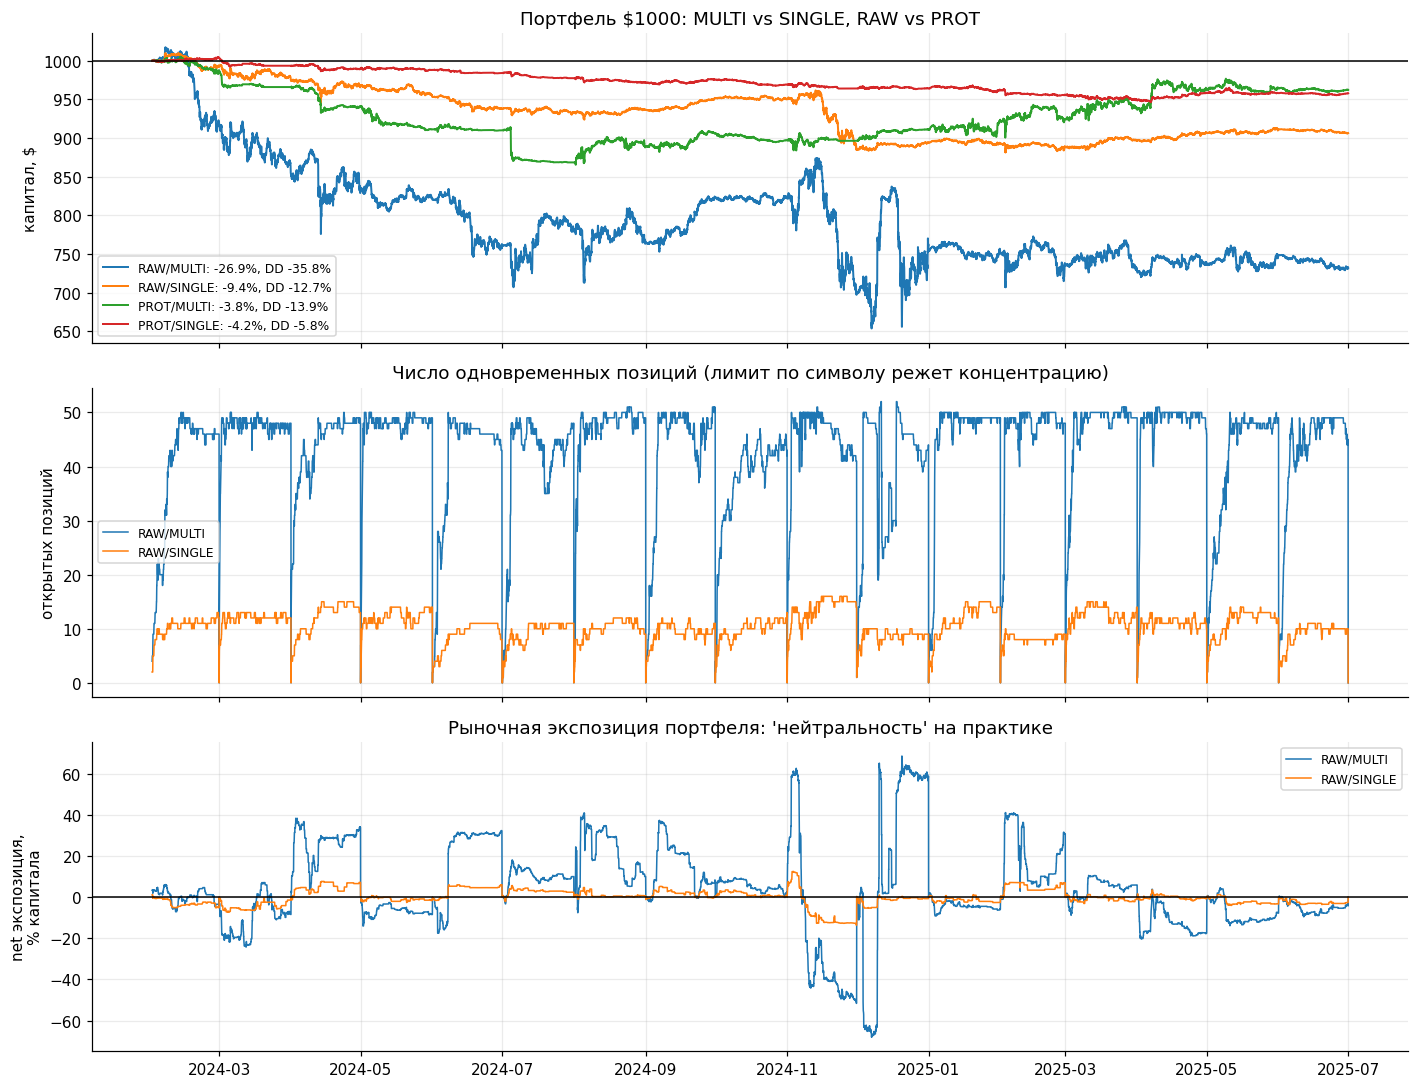

In [6]:
fig, ax = plt.subplots(3, 1, figsize=(13, 10), sharex=True)
for tag, (eq, log, st, diag) in RUNS.items():
    ax[0].plot(eq.index, eq.values, lw=1.3, label=f"{tag}: {st['доход %']:+.1f}%, DD {st['MTM maxDD %']:.1f}%")
ax[0].axhline(1000, color="black", lw=1)
ax[0].set_ylabel("капитал, $"); ax[0].set_title("Портфель $1000: MULTI vs SINGLE, RAW vs PROT")
ax[0].legend(fontsize=8)

for tag in ["RAW/MULTI", "RAW/SINGLE"]:
    d = RUNS[tag][3]
    ax[1].plot(d.index, d.n_open.values, lw=1.0, label=tag)
ax[1].set_ylabel("открытых позиций"); ax[1].legend(fontsize=8)
ax[1].set_title("Число одновременных позиций (лимит по символу режет концентрацию)")

for tag in ["RAW/MULTI", "RAW/SINGLE"]:
    d = RUNS[tag][3]
    ax[2].plot(d.index, d.net_exp.values*100, lw=1.0, label=tag)
ax[2].axhline(0, color="black", lw=1)
ax[2].set_ylabel("net экспозиция,\n% капитала")
ax[2].set_title("Рыночная экспозиция портфеля: 'нейтральность' на практике")
ax[2].legend(fontsize=8)
show("nb04_portfolio")

## 4. Проверка опыта пользователя: умирает ли портфель на трендовом рынке

Пользователь: «была рабочая парная стратегия, но она умирала, когда весь рынок
становился трендовым». Это проверяемое утверждение. Меряем **трендовость месяца**
двумя способами:

- **направленность** = |суммарная доходность равновзвешенного индекса за месяц|
  (сильный тренд в любую сторону);
- **эффективность тренда** = |сумма доходностей| / сумма |доходностей| (насколько
  движение однонаправленное, а не пила).

И смотрим, как с ними связана месячная доходность портфеля.

СВЯЗЬ ДОХОДНОСТИ ПОРТФЕЛЯ С ТРЕНДОВОСТЬЮ РЫНКА
     конфиг  corr(мес. PnL, |тренд рынка|)  corr(мес. PnL, эффективность тренда) плюсовых месяцев
  RAW/MULTI                         -0.600                                -0.627             6/16
 RAW/SINGLE                         -0.684                                -0.678             6/16
 PROT/MULTI                         -0.096                                -0.158             8/16
PROT/SINGLE                         -0.289                                -0.278             3/16

помесячно (RAW/MULTI):
                           PnL портфеля %  рынок за мес %  эффективность  режим
timestamp                                                                      
2024-03-01 00:00:00+00:00            -7.2            18.6           0.04   пила
2024-04-01 00:00:00+00:00            -1.8           -38.1           0.08  ТРЕНД
2024-05-01 00:00:00+00:00            -1.8            17.8           0.05  ТРЕНД
2024-06-01 00:00:00+00:00            -7

WindowsPath('C:/projects/researchlab/notebooks/statarb/_out/nb04_regime.png')

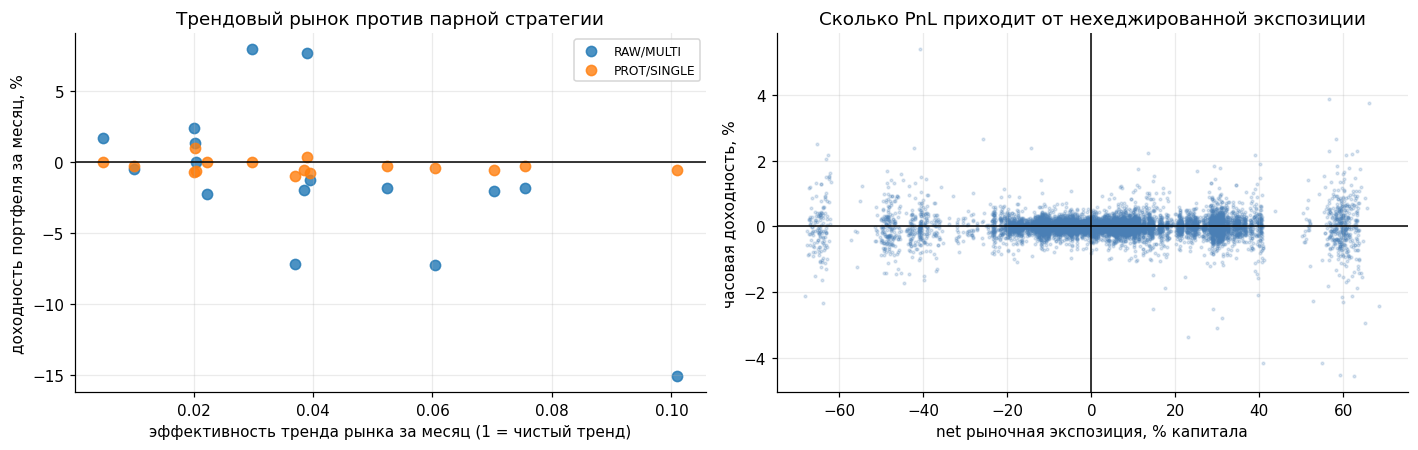

In [7]:
mret = MKT.resample("MS").sum()                       # доходность индекса за месяц
mabs = MKT.abs().resample("MS").sum()
eff = (mret.abs() / mabs).rename("эффективность")      # 0 = пила, 1 = чистый тренд

rows = []
for tag, (eq, log, st, diag) in RUNS.items():
    m = eq.resample("MS").last().pct_change().dropna() * 100
    idx = m.index.intersection(mret.index)
    r_dir = float(np.corrcoef(m.loc[idx], mret.loc[idx].abs())[0, 1])
    r_eff = float(np.corrcoef(m.loc[idx], eff.loc[idx])[0, 1])
    rows.append({"конфиг": tag,
                 "corr(мес. PnL, |тренд рынка|)": round(r_dir, 3),
                 "corr(мес. PnL, эффективность тренда)": round(r_eff, 3),
                 "плюсовых месяцев": f"{(m>0).sum()}/{len(m)}"})
print("СВЯЗЬ ДОХОДНОСТИ ПОРТФЕЛЯ С ТРЕНДОВОСТЬЮ РЫНКА")
print(pd.DataFrame(rows).to_string(index=False))

eq = RUNS["RAW/MULTI"][0]
m = eq.resample("MS").last().pct_change().dropna() * 100
idx = m.index.intersection(eff.index)
tab = pd.DataFrame({"PnL портфеля %": m.loc[idx].round(1),
                    "рынок за мес %": (mret.loc[idx]*100).round(1),
                    "эффективность": eff.loc[idx].round(2)})
tab["режим"] = np.where(tab["эффективность"] > tab["эффективность"].median(),
                        "ТРЕНД", "пила")
print("\nпомесячно (RAW/MULTI):")
print(tab.to_string())
print("\nсредняя доходность портфеля по режиму:")
print(tab.groupby("режим")["PnL портфеля %"].agg(["size", "mean", "median"]).round(2).to_string())

fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
for tag in ["RAW/MULTI", "PROT/SINGLE"]:
    e = RUNS[tag][0].resample("MS").last().pct_change().dropna()*100
    i2 = e.index.intersection(eff.index)
    ax[0].scatter(eff.loc[i2], e.loc[i2], s=45, alpha=0.8, label=tag)
ax[0].axhline(0, color="black", lw=1)
ax[0].set_xlabel("эффективность тренда рынка за месяц (1 = чистый тренд)")
ax[0].set_ylabel("доходность портфеля за месяц, %")
ax[0].set_title("Трендовый рынок против парной стратегии"); ax[0].legend(fontsize=8)

d = RUNS["RAW/MULTI"][3]
ax[1].scatter(d.net_exp*100, np.r_[0, np.diff(d.equity)]/d.equity*100, s=3, alpha=0.2,
              color="#4a7fb5")
ax[1].axhline(0, color="black", lw=1); ax[1].axvline(0, color="black", lw=1)
ax[1].set_xlabel("net рыночная экспозиция, % капитала")
ax[1].set_ylabel("часовая доходность, %")
ax[1].set_title("Сколько PnL приходит от нехеджированной экспозиции")
show("nb04_regime")